<a href="https://colab.research.google.com/github/AnanyaAsthana/Digital-Image-Processing/blob/main/dip_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
size = 512
x = np.linspace(0, 1, size)
y = np.linspace(0, 1, size)
X, Y = np.meshgrid(x, y)

image_continuous = 0.5 + 0.5 * np.sin(10 * np.pi * X) * np.cos(10 * np.pi * Y)

In [ ]:
sampling_factor = 8
image_sampled = image_continuous[::sampling_factor, ::sampling_factor]


In [ ]:
quant_levels = 8
image_quantized = np.floor(image_sampled * quant_levels) / quant_levels


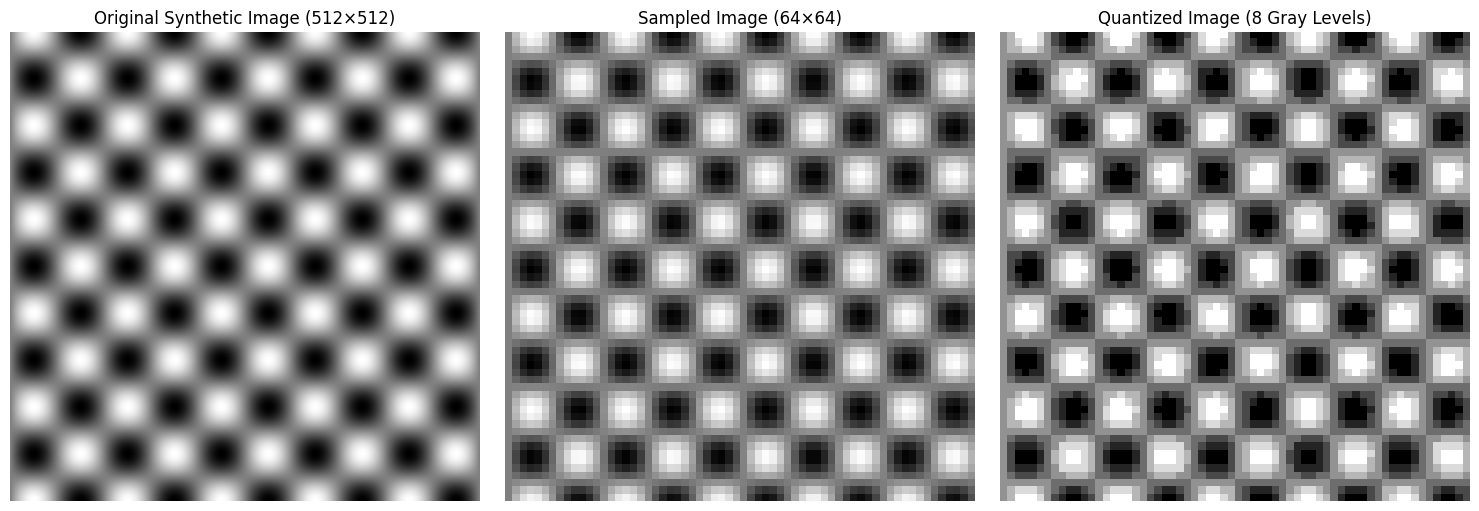

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_continuous, cmap='gray')
plt.title("Original Synthetic Image (512×512)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_sampled, cmap='gray')
plt.title(f"Sampled Image ({size//sampling_factor}×{size//sampling_factor})")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_quantized, cmap='gray')
plt.title(f"Quantized Image ({quant_levels} Gray Levels)")
plt.axis('off')

plt.tight_layout()
plt.show()

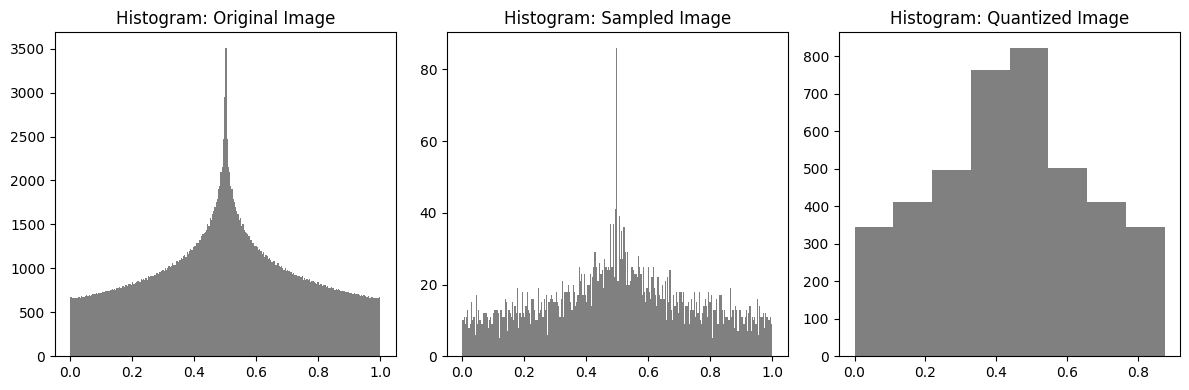

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(image_continuous.flatten(), bins=256, color='gray')
plt.title("Histogram: Original Image")

plt.subplot(1, 3, 2)
plt.hist(image_sampled.flatten(), bins=256, color='gray')
plt.title("Histogram: Sampled Image")

plt.subplot(1, 3, 3)
plt.hist(image_quantized.flatten(), bins=quant_levels, color='gray')
plt.title("Histogram: Quantized Image")

plt.tight_layout()
plt.show()

In [ ]:
import math

In [ ]:
image_size = (1024, 1024)

# Pixel coordinates
p1 = (200, 300)
p2 = (700, 900)

# Coordinate differences
dx = abs(p2[0] - p1[0])
dy = abs(p2[1] - p1[1])

In [ ]:
# 1. Euclidean Distance (De)
De = math.sqrt(dx**2 + dy**2)

# 2. City Block Distance (D4)
D4 = dx + dy

# 3. Chessboard Distance (D8)
D8 = max(dx, dy)

In [ ]:
print("Pixel 1:", p1)
print("Pixel 2:", p2)
print("Image Size:", image_size)
print("\nDistance Results:")
print("Euclidean Distance (De):", De)
print("City Block Distance (D4):", D4)
print("Chessboard Distance (D8):", D8)

Pixel 1: (200, 300)
Pixel 2: (700, 900)
Image Size: (1024, 1024)

Distance Results:
Euclidean Distance (De): 781.0249675906655
City Block Distance (D4): 1100
Chessboard Distance (D8): 600


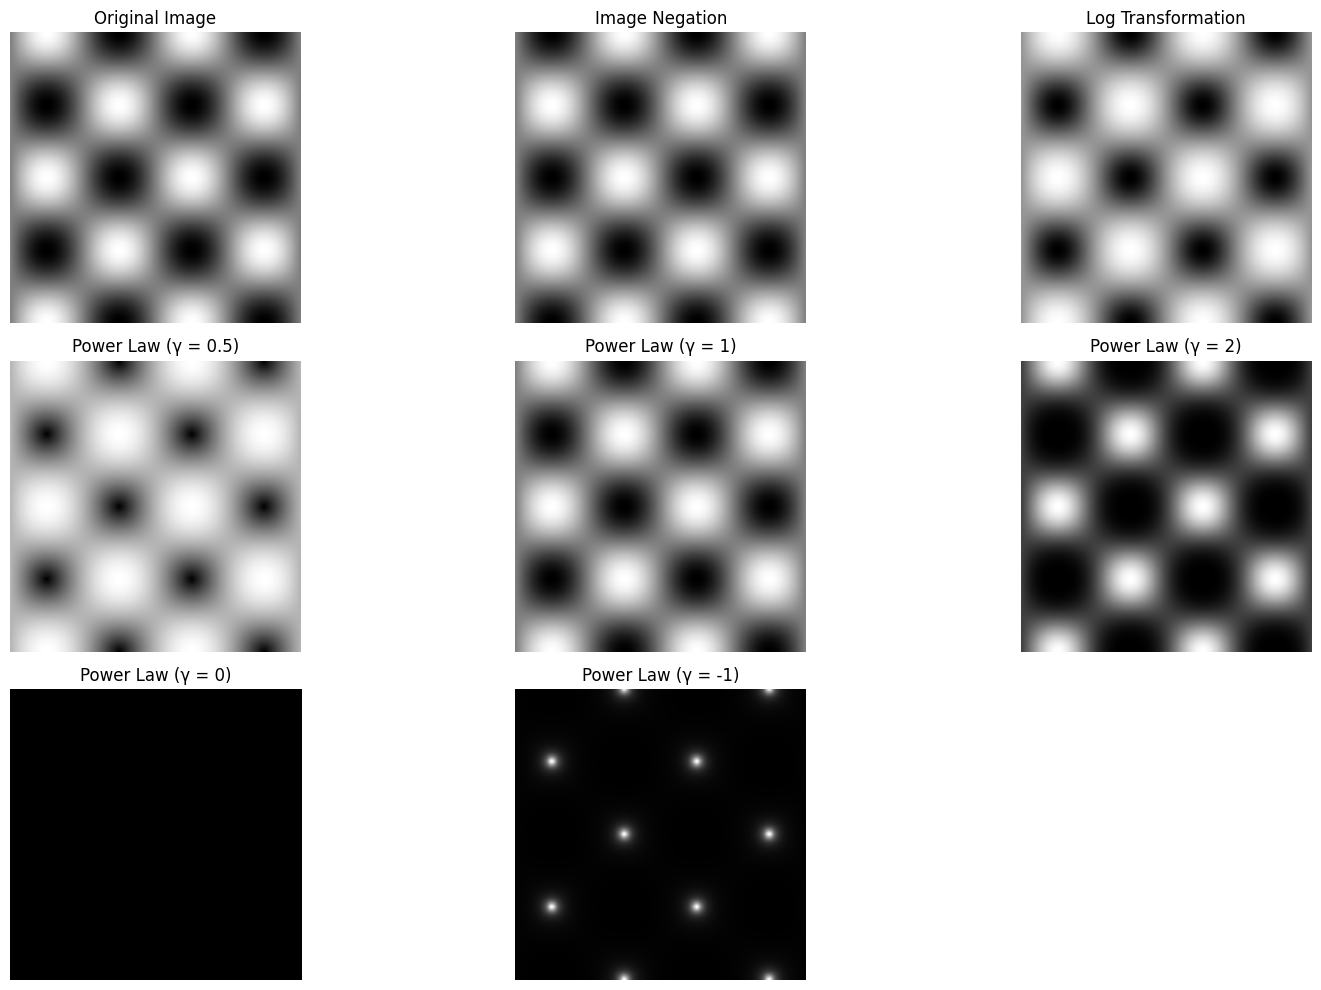

In [ ]:
# =====================================================
# Image Negation, Log, and Power-Law Transformations
# GUARANTEED KeyError-Free
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. Create Synthetic Image
# ---------------------------------------------
size = 256
x = np.linspace(0, 1, size)
y = np.linspace(0, 1, size)
X, Y = np.meshgrid(x, y)

image = 0.5 + 0.5 * np.sin(4 * np.pi * X) * np.cos(4 * np.pi * Y)
image = (image - image.min()) / (image.max() - image.min())

# ---------------------------------------------
# 2. Image Negation
# ---------------------------------------------
image_neg = 1 - image

# ---------------------------------------------
# 3. Log Transformation
# ---------------------------------------------
c = 1 / np.log(1 + np.max(image))
image_log = c * np.log(1 + image)

# ---------------------------------------------
# 4. Power Law Transformations
# ---------------------------------------------
gamma_0   = np.ones_like(image)                  # γ = 0
gamma_05  = np.power(image, 0.5)                 # γ = 0.5
gamma_1   = np.power(image, 1)                   # γ = 1
gamma_2   = np.power(image, 2)                   # γ = 2
gamma_neg = np.power(image + 0.01, -1)           # γ = -1 (avoid /0)

# ---------------------------------------------
# 5. Display Results
# ---------------------------------------------
plt.figure(figsize=(16, 10))

plt.subplot(3, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(image_neg, cmap='gray')
plt.title("Image Negation")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(image_log, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(gamma_05, cmap='gray')
plt.title("Power Law (γ = 0.5)")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(gamma_1, cmap='gray')
plt.title("Power Law (γ = 1)")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(gamma_2, cmap='gray')
plt.title("Power Law (γ = 2)")
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(gamma_0, cmap='gray')
plt.title("Power Law (γ = 0)")
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(gamma_neg, cmap='gray')
plt.title("Power Law (γ = -1)")
plt.axis('off')

plt.tight_layout()
plt.show()


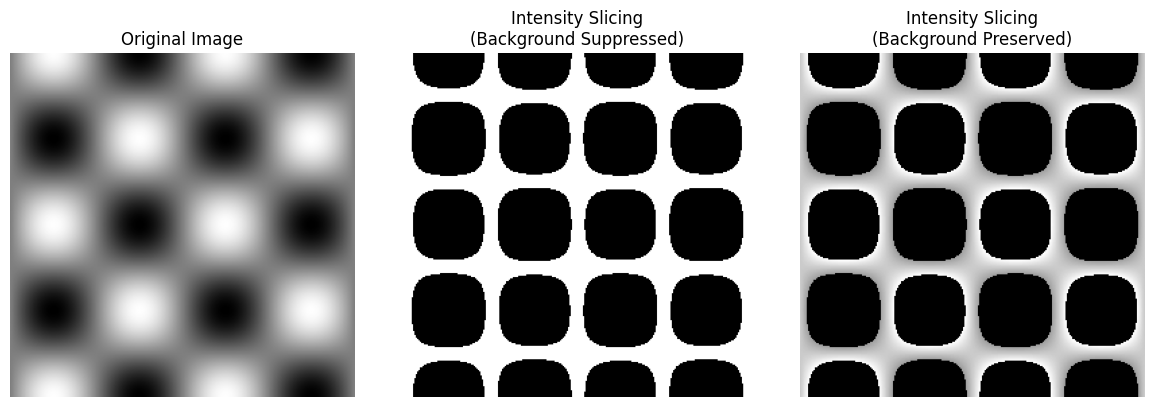

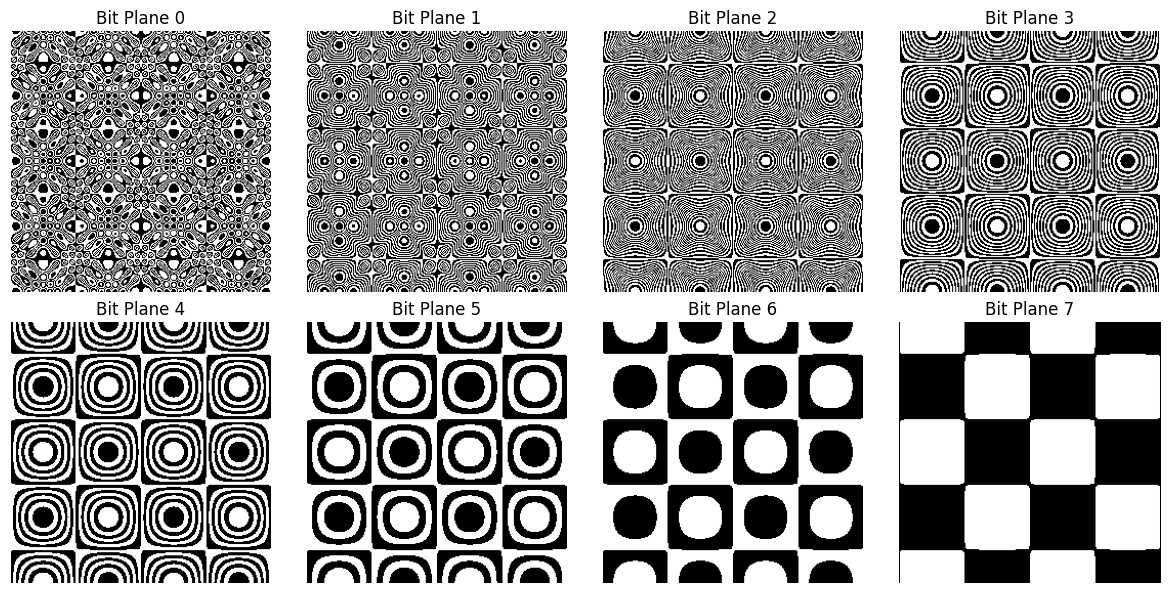

In [ ]:
# =====================================================
# Intensity Level Slicing and Bit Level Slicing
# Google Colab Ready
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. Create Synthetic Grayscale Image
# ---------------------------------------------
size = 256
x = np.linspace(0, 1, size)
y = np.linspace(0, 1, size)
X, Y = np.meshgrid(x, y)

image = 0.5 + 0.5 * np.sin(4 * np.pi * X) * np.cos(4 * np.pi * Y)

# Normalize and convert to 8-bit image
image = (image - image.min()) / (image.max() - image.min())
image_8bit = (image * 255).astype(np.uint8)

# ---------------------------------------------
# 2. Intensity Level Slicing
# ---------------------------------------------
# Define intensity range
low, high = 100, 160

# With background suppressed
slice_no_bg = np.zeros_like(image_8bit)
slice_no_bg[(image_8bit >= low) & (image_8bit <= high)] = 255

# With background preserved
slice_with_bg = image_8bit.copy()
slice_with_bg[(image_8bit < low) | (image_8bit > high)] = 0

# ---------------------------------------------
# 3. Bit Level (Bit Plane) Slicing
# ---------------------------------------------
bit_planes = []

for bit in range(8):
    bit_plane = (image_8bit >> bit) & 1
    bit_planes.append(bit_plane * 255)

# ---------------------------------------------
# 4. Display Intensity Level Slicing
# ---------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_8bit, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(slice_no_bg, cmap='gray')
plt.title("Intensity Slicing\n(Background Suppressed)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(slice_with_bg, cmap='gray')
plt.title("Intensity Slicing\n(Background Preserved)")
plt.axis('off')

plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5. Display Bit Level Slicing
# ---------------------------------------------
plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(bit_planes[i], cmap='gray')
    plt.title(f"Bit Plane {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()


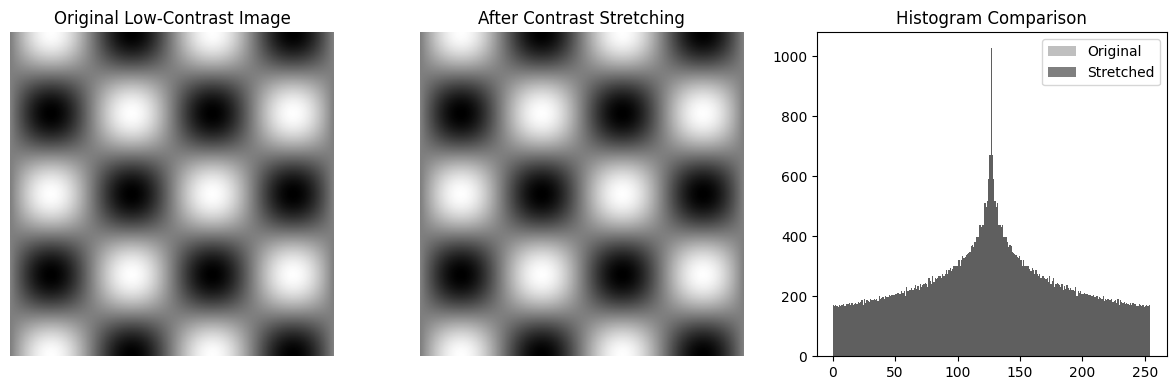

In [ ]:
# =====================================================
# Contrast Stretching on a Synthetic Image
# Google Colab Ready
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. Create Synthetic Low-Contrast Image
# ---------------------------------------------
size = 256
x = np.linspace(0, 1, size)
y = np.linspace(0, 1, size)
X, Y = np.meshgrid(x, y)

# Create a low-contrast image (values squeezed)
image = 0.5 + 0.1 * np.sin(4 * np.pi * X) * np.cos(4 * np.pi * Y)

# Normalize and convert to 8-bit
image = (image - image.min()) / (image.max() - image.min())
image_8bit = (image * 255).astype(np.uint8)

# ---------------------------------------------
# 2. Contrast Stretching
# ---------------------------------------------
r_min = np.min(image_8bit)
r_max = np.max(image_8bit)

# Stretch intensity values to full range [0,255]
stretched = ((image_8bit - r_min) / (r_max - r_min)) * 255
stretched = stretched.astype(np.uint8)

# ---------------------------------------------
# 3. Display Images
# ---------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_8bit, cmap='gray')
plt.title("Original Low-Contrast Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(stretched, cmap='gray')
plt.title("After Contrast Stretching")
plt.axis('off')

# ---------------------------------------------
# 4. Histogram Comparison
# ---------------------------------------------
plt.subplot(1, 3, 3)
plt.hist(image_8bit.flatten(), bins=256, color='gray', alpha=0.5, label='Original')
plt.hist(stretched.flatten(), bins=256, color='black', alpha=0.5, label='Stretched')
plt.title("Histogram Comparison")
plt.legend()

plt.tight_layout()
plt.show()


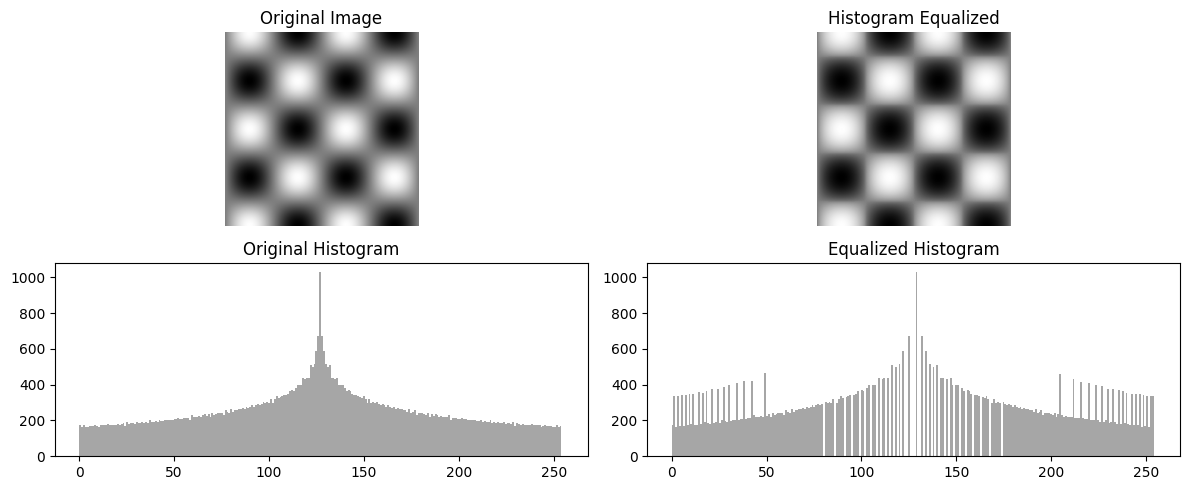

In [ ]:
# =====================================================
# Histogram Equalization on a Synthetic Image
# Google Colab Ready
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. Create a Synthetic Low-Contrast Image
# ---------------------------------------------
size = 256
x = np.linspace(0, 1, size)
y = np.linspace(0, 1, size)
X, Y = np.meshgrid(x, y)

# Low-contrast image
image = 0.5 + 0.1 * np.sin(4 * np.pi * X) * np.cos(4 * np.pi * Y)

# Convert to 8-bit grayscale
image = (image - image.min()) / (image.max() - image.min())
image_8bit = (image * 255).astype(np.uint8)

# ---------------------------------------------
# 2. Histogram Equalization
# ---------------------------------------------
# Compute histogram
hist, bins = np.histogram(image_8bit.flatten(), bins=256, range=[0,256])

# Compute cumulative distribution function (CDF)
cdf = hist.cumsum()
cdf_normalized = cdf * 255 / cdf[-1]  # normalize to [0,255]

# Map original pixels through CDF
image_eq = np.interp(image_8bit.flatten(), bins[:-1], cdf_normalized)
image_eq = image_eq.reshape(image_8bit.shape).astype(np.uint8)

# ---------------------------------------------
# 3. Display Images and Histograms
# ---------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(2, 2, 1)
plt.imshow(image_8bit, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(image_eq, cmap='gray')
plt.title("Histogram Equalized")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(image_8bit.flatten(), bins=256, color='gray', alpha=0.7)
plt.title("Original Histogram")

plt.subplot(2, 2, 4)
plt.hist(image_eq.flatten(), bins=256, color='gray', alpha=0.7)
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()
